# Social Network Advertisement Analysis

# 1. Project Overview

This project aims to predict the users on the social network who, on the basis of interacting with the advertisement either purchased the product or not? using the "Social_Network_Ads.csv" Dataset.

# 2. Glimpse of Analysis

In [109]:
"""
Problem Statement  : Predict if the product is purchsed or not, on the basis of Social Network Ads.
Observation        : Here, predicting whether purchased or not is the Target and since it is Discrete/Categorical in nature. We will apply Logistic Regression Models.

Data Description :
Shape   : (400, 5)
Rows    : 400 (0 to 399)
Columns : 5
dtypes  : int64(4), object(1)

Data Preprocessing :
Null values        : None
Duplicate values   : None
Outliers           : None
Skewness           : Negligible
NaN Values         : None (Checked for any remaining NaN values)
Feature Scaling    : Applied StaandardScaler

Train/Test Split   :
Creating 80% to 20% ratio of Dataset for training the regression model
Training Set Shape : (320, 4) (1320,) / (xtran, ytrain)
Testing Set Shape  : (80, 4) (80,) / (xtest, ytest)

Applied Regression Models :
Logistic Regression       : 0.82
AUC-ROC Score             : 0.82
Decision Tree Classifier  : 0.89 (High Accuracy Model)
Random Forest Classifier  : 0.89 (High Accuracy Model)
AdaBoosting Classifier    : 0.88
Gradient Boosting         : 0.90 (High Accuracy Model)
XGBoost Classifier        : 0.88

Confusion Matrix :
 ____________________________________________
|               | Not Purchased | Purchased |
|---------------|---------------|-----------|
| Not Purchased |       44      |      7    |
| Purchased     |        6      |     23    |
|_______________|_______________|___________|

Classification Report :
 ____________________________________________________________
|              |  precision |  recall | f1-score  | support |
|--------------|------------|---------|-----------|---------|
|           0  |     0.96   |   0.88  |    0.92   |     51  |
|           1  |     0.82   |   0.93  |    0.87   |     29  |
|--------------|------------|---------|-----------|---------|
|    accuracy  |            |         |    0.90   |     80  |
|   macro avg  |     0.89   |   0.91  |    0.89   |     80  |
| weighted avg |     0.91   |   0.90  |    0.90   |     80  |
|______________|____________|_________|___________|_________|

"""

'\nProblem Statement  : Predict if the product is purchsed or not, on the basis of Social Network Ads.\nObservation        : Here, predicting whether purchased or not is the Target and since it is Discrete/Categorical in nature. We will apply Logistic Regression Models.\n\nData Description :\nShape   : (400, 5)\nRows    : 400 (0 to 399)\nColumns : 5\ndtypes  : int64(4), object(1)\n\nData Preprocessing :\nNull values        : None\nDuplicate values   : None\nOutliers           : None\nSkewness           : Negligible\nNaN Values         : None (Checked for any remaining NaN values)\nFeature Scaling    : Applied StaandardScaler\n\nTrain/Test Split   :\nCreating 80% to 20% ratio of Dataset for training the regression model\nTraining Set Shape : (320, 4) (1320,) / (xtran, ytrain)\nTesting Set Shape  : (80, 4) (80,) / (xtest, ytest)\n\nApplied Regression Models :\nLogistic Regression       : 0.82\nAUC-ROC Score             : 0.82\nDecision Tree Classifier  : 0.89 (High Accuracy Model)\nRando

# 3. Workflow

# A ] Data Loading :

# _Step 1: Importing Libraries_

In [105]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

from scipy.stats import skew
from sklearn.preprocessing import OrdinalEncoder, StandardScaler, binarize
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier

from sklearn import tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score, roc_curve

# _Step 2: Load Dataset_

In [56]:
df = pd.read_csv("Social_Network_Ads.csv")
print("Initial Shape of Dataset:", df.shape)
df.head()

Initial Shape of Dataset: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


In [57]:
print("Data Info:")
df.info()

Data Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   User ID          400 non-null    int64 
 1   Gender           400 non-null    object
 2   Age              400 non-null    int64 
 3   EstimatedSalary  400 non-null    int64 
 4   Purchased        400 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 15.8+ KB


In [58]:
print("Data Description:")
df.describe()

Data Description:


,User ID,Age,EstimatedSalary,Purchased
count,4.000000e+02,400.000000,400.000000,400.000000
mean,1.569154e+07,37.655000,69742.500000,0.357500
std,7.165832e+04,10.482877,34096.960282,0.479864
min,1.556669e+07,18.000000,15000.000000,0.000000
25%,1.562676e+07,29.750000,43000.000000,0.000000
50%,1.569434e+07,37.000000,70000.000000,0.000000
75%,1.575036e+07,46.000000,88000.000000,1.000000
max,1.581524e+07,60.000000,150000.000000,1.000000


# B ] EDA (Exploratory Data Analysis) :

# _Step 1: Missing Value Analysis_

In [59]:
(df.isnull().sum())/len(df)*100

User ID            0.0
Gender             0.0
Age                0.0
EstimatedSalary    0.0
Purchased          0.0
dtype: float64

# _Step 2: Values Distribution with Visualization_

In [60]:
df.columns

Index(['User ID', 'Gender', 'Age', 'EstimatedSalary', 'Purchased'], dtype='object')

In [61]:
df['User ID'].value_counts()

User ID
15594041    1
15624510    1
15810944    1
15668575    1
15603246    1
           ..
15621083    1
15649487    1
15736760    1
15714658    1
15599081    1
Name: count, Length: 400, dtype: int64

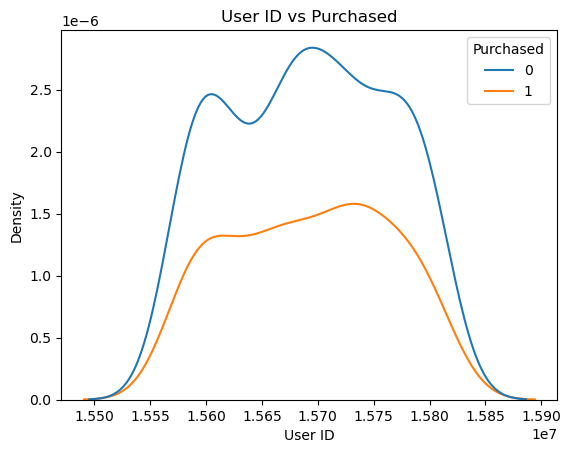

In [62]:
sns.kdeplot(data=df, x='User ID', hue='Purchased')
plt.title('User ID vs Purchased')
plt.show()

In [63]:
df['Gender'].value_counts()

Gender
Female    204
Male      196
Name: count, dtype: int64

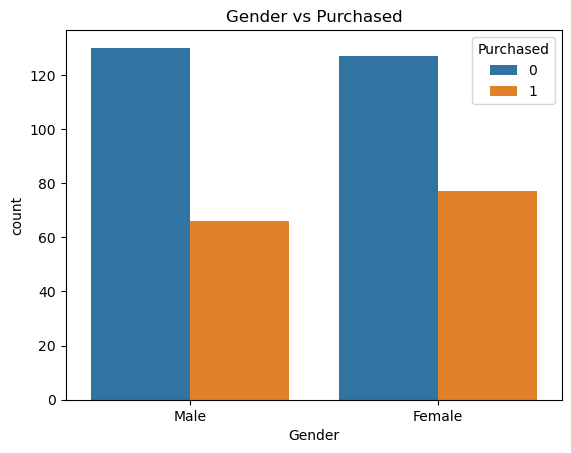

In [64]:
sns.countplot(data=df, x='Gender', hue='Purchased')
plt.title('Gender vs Purchased')
plt.show()

In [65]:
print(f"The Oldest People are of Age : ", df['Age'].max())
print(f"\nThe Youngest People are of Age : ", df['Age'].min())

The Oldest People are of Age :  60

The Youngest People are of Age :  18


In [66]:
df['Age'].value_counts()

Age
35    32
37    20
26    16
42    16
41    16
39    15
40    15
48    14
47    14
27    13
38    13
36    12
46    12
28    12
30    11
31    11
49    10
29    10
32     9
24     9
33     9
60     7
45     7
19     7
59     7
20     7
25     6
52     6
58     6
23     6
34     6
18     5
22     5
57     5
53     5
21     4
54     4
50     4
55     3
51     3
56     3
43     3
44     2
Name: count, dtype: int64

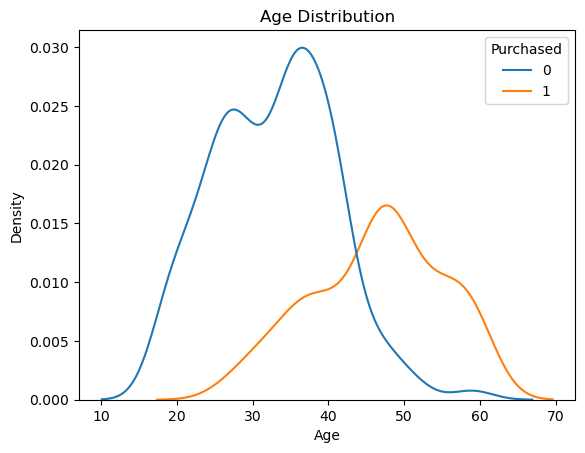

In [67]:
sns.kdeplot(data=df, x='Age', hue='Purchased')
plt.title('Age Distribution')
plt.show()

In [68]:
df['EstimatedSalary'].value_counts()

EstimatedSalary
72000     12
80000     11
79000     10
75000      9
71000      9
          ..
99000      1
129000     1
46000      1
64000      1
139000     1
Name: count, Length: 117, dtype: int64

In [69]:
df['EstimatedSalary'].describe()

count       400.000000
mean      69742.500000
std       34096.960282
min       15000.000000
25%       43000.000000
50%       70000.000000
75%       88000.000000
max      150000.000000
Name: EstimatedSalary, dtype: float64

<Axes: xlabel='EstimatedSalary', ylabel='Density'>

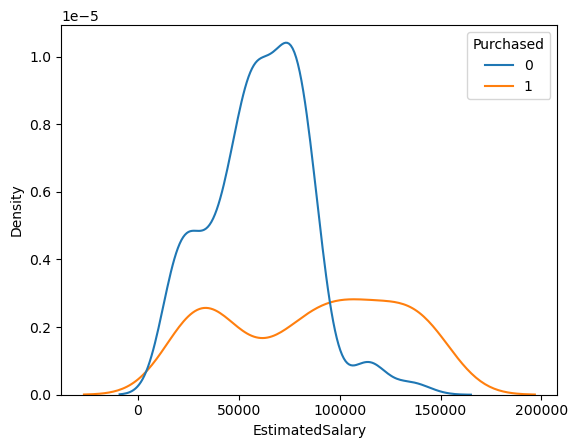

In [70]:
sns.kdeplot(data=df, x='EstimatedSalary', hue='Purchased')

In [71]:
df['Purchased'].value_counts()

Purchased
0    257
1    143
Name: count, dtype: int64

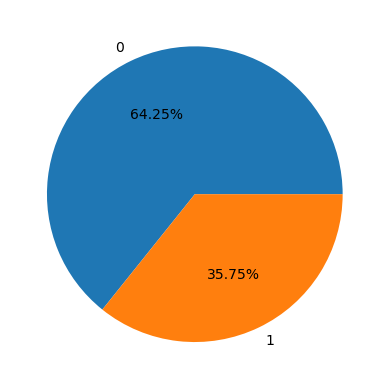

In [72]:
plt.pie(df['Purchased'].value_counts(),autopct="%.2f%%",labels=df['Purchased'].unique())
plt.show()

# _Step 3: Outliers Check_

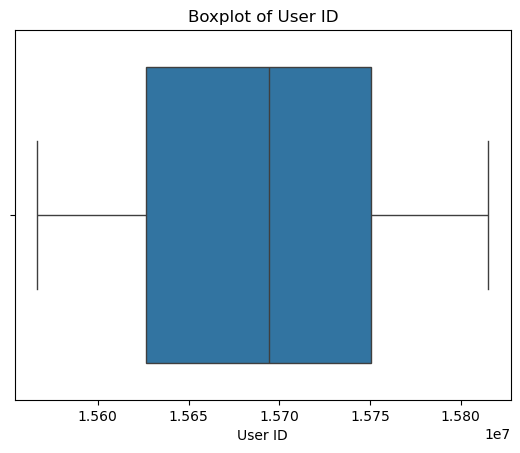

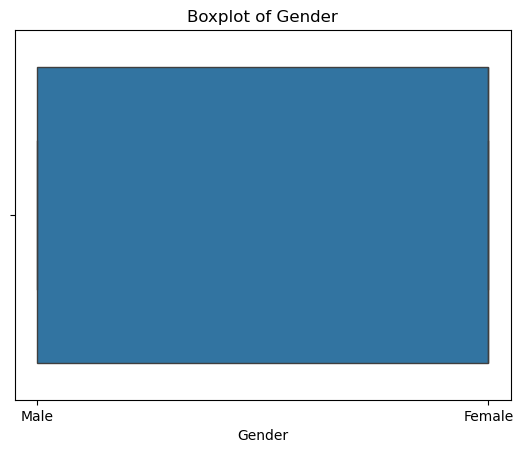

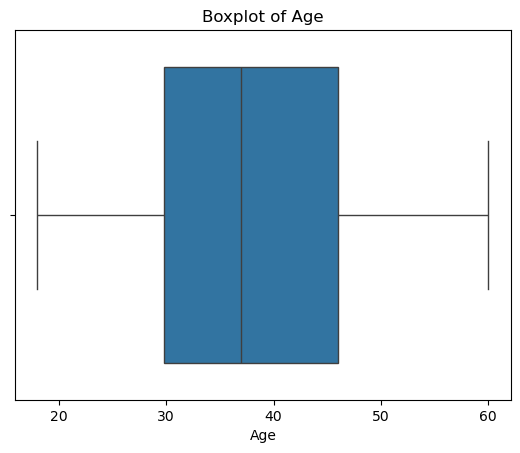

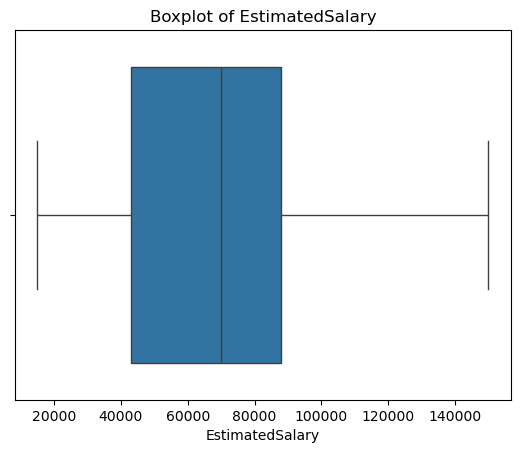

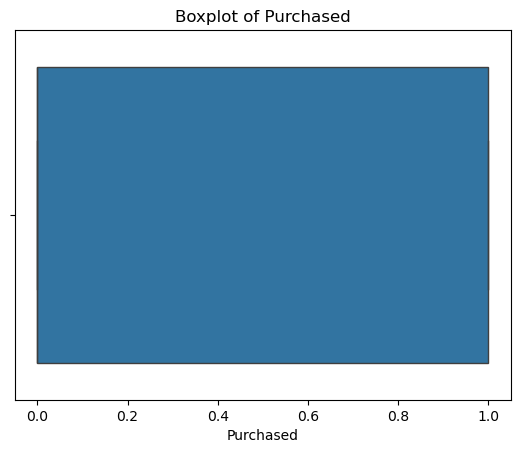

In [73]:
for col in df:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

# _Step 4: Handling Object Datatypes_

In [74]:
cat_col = df.select_dtypes("object").columns
cat_col

Index(['Gender'], dtype='object')

In [75]:
enc = OrdinalEncoder()
df[cat_col] = enc.fit_transform(df[cat_col])
df[cat_col]

,Gender
0,1.0
1,1.0
2,0.0
3,0.0
4,1.0
...,...
395,0.0
396,1.0
397,0.0
398,1.0


# C ] Feature Scaling :

# _Step 1: Separation of Featues & Target_

In [76]:
features = df.drop('Purchased', axis=1)
target = df['Purchased']

# _Step 2: Scaling Method - Standardization_

In [77]:
scaler = StandardScaler()
features.iloc[:] = scaler.fit_transform(features.iloc[:])
features.head()

,User ID,Gender,Age,EstimatedSalary
0,-0.936579,1.020204,-1.781797,-1.490046
1,1.668387,1.020204,-0.253587,-1.460681
2,-0.320877,-0.980196,-1.113206,-0.785290
3,-1.233692,-0.980196,-1.017692,-0.374182
4,1.571389,1.020204,-1.781797,0.183751


# D ] Train-Test Split :

In [78]:
# Model Training by giving 80% of training set and 20% of Testing set-
xtrain,xtest,ytrain,ytest = train_test_split(features, target, test_size=0.2, random_state=1, stratify=target)

In [79]:
# Verifying, if number of rows for Training & Testing are equal or not-
print(xtrain.shape, ytrain.shape)
print(xtest.shape, ytest.shape)

(320, 4) (320,)
(80, 4) (80,)


# E ] Applying Logistic Regression :

In [80]:
lgr = LogisticRegression()
lgr.fit(xtrain, ytrain)
ypred = lgr.predict(xtest)

In [81]:
c = pd.DataFrame(confusion_matrix(ytest, ypred), index=["Not Purchased", "Purchased"],
                 columns = ["Not Purchased", "Purchased"])
print(f"Confusion Matrix : \n", c)
print(f"Classification Report : \n", classification_report(ytest, ypred))

Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             46          5
Purchased                  9         20
Classification Report : 
               precision    recall  f1-score   support

           0       0.84      0.90      0.87        51
           1       0.80      0.69      0.74        29

    accuracy                           0.82        80
   macro avg       0.82      0.80      0.80        80
weighted avg       0.82      0.82      0.82        80



# F ] Checking Train-Test Scores :

In [82]:
lgr.score(xtrain, ytrain)

0.859375

In [83]:
lgr.score(xtest, ytest)

0.825

# G ] Comparing Probability of Success & Failure :

In [84]:
print(ytest[:25].values)
print(ypred[:25])

[0 0 0 0 0 1 0 1 1 1 0 0 0 0 0 0 0 1 0 1 1 1 0 0 1]
[0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 0 0]


In [85]:
# class assigned by gerater probability----[class 0, class 1]
lgr.predict_proba(xtest[:10])

array([[0.99862576, 0.00137424],
       [0.68479676, 0.31520324],
       [0.99773738, 0.00226262],
       [0.94339249, 0.05660751],
       [0.99527446, 0.00472554],
       [0.00182029, 0.99817971],
       [0.9144848 , 0.0855152 ],
       [0.57466989, 0.42533011],
       [0.6545037 , 0.3454963 ],
       [0.75912314, 0.24087686]])

# H ] AUC-ROC Curve :

In [86]:
roc_auc_score(ytest, ypred)

np.float64(0.7958079783637593)

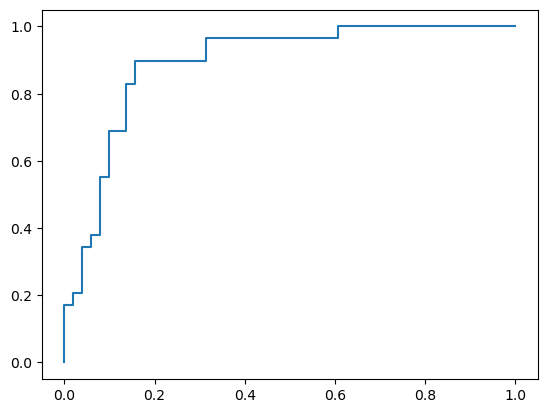

In [87]:
yp = lgr.predict_proba(xtest[:])
yp = yp[:,1]
fpr, tpr, threshold = roc_curve(ytest, yp)
plt.plot(fpr, tpr)
plt.show()

In [88]:
ypred_proba = lgr.predict_proba(xtest)[:,1]
ypr = binarize([ypred_proba], threshold=0.4)[0]
ypr = ypr.astype(int)

In [89]:
roc_auc_score(ytest, ypred)
# minute increase

np.float64(0.7958079783637593)

In [90]:
c = pd.DataFrame(confusion_matrix(ytest, ypr), index=["Not Purchased", "Purchased"],
                 columns = ["Not Purchased", "Purchased"])
print(f"Confusion Matrix : \n", c)
print(f"Classification Report : \n", classification_report(ytest, ypr))

Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.88      0.86      0.87        51
           1       0.77      0.79      0.78        29

    accuracy                           0.84        80
   macro avg       0.82      0.83      0.83        80
weighted avg       0.84      0.84      0.84        80



# I ] Applying Other Classifier Models :

In [91]:
def mymodel(model):
    model.fit(xtrain, ytrain)
    ypred=model.predict(xtest)
    # overfitting-underfitting check
    train_score=model.score(xtrain, ytrain)
    test_score=model.score(xtest, ytest)
    print("Training Score : ", train_score)
    print("Testing Score : ", test_score)
    c = pd.DataFrame(confusion_matrix(ytest, ypr),
                     index=["Not Purchased", "Purchased"],
                     columns = ["Not Purchased", "Purchased"])
    print(f"Confusion Matrix : \n", c)
    print(f"Classification Report : \n", classification_report(ytest, ypred))
    return model

- 1. Decision Tree Classifier -

In [92]:
dt=mymodel(DecisionTreeClassifier())
dt
# Increased Accuracy from 84% to 89%.

Training Score :  1.0
Testing Score :  0.8625
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.90      0.88      0.89        51
           1       0.80      0.83      0.81        29

    accuracy                           0.86        80
   macro avg       0.85      0.85      0.85        80
weighted avg       0.86      0.86      0.86        80



DecisionTreeClassifier()

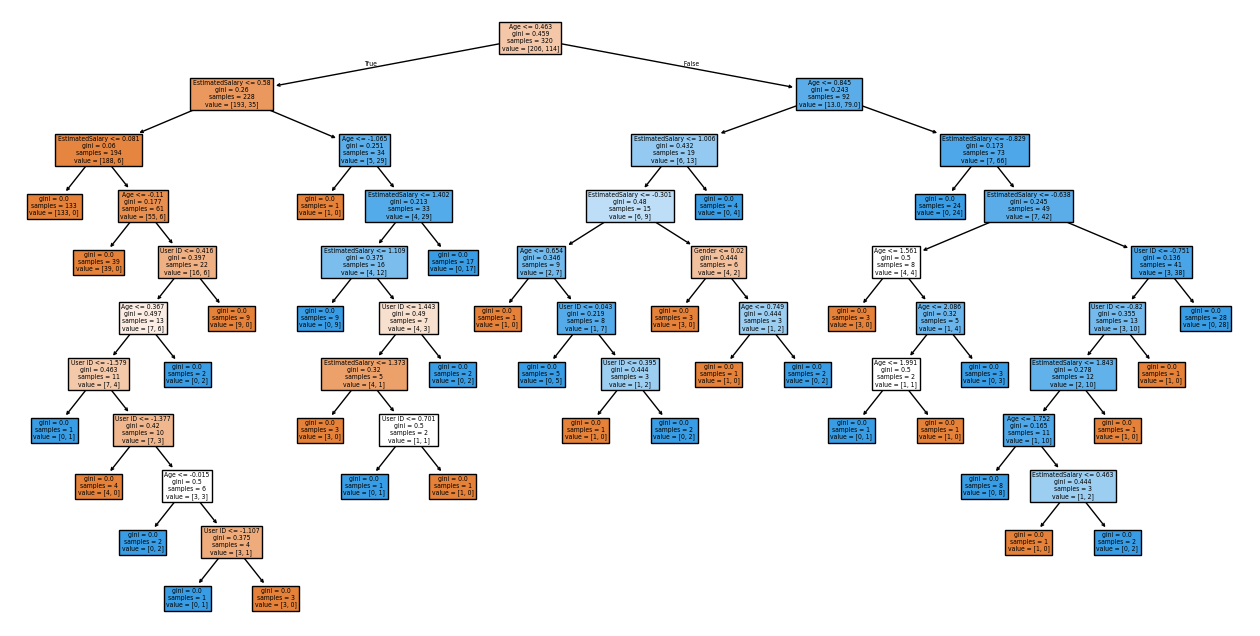

In [93]:
plt.figure(figsize=(16,8))
tree.plot_tree(dt, feature_names = features.columns, filled=True)
plt.show()

In [94]:
# Get Depth and Number of Leaves of Decision Tree-
print(f"Depth : {dt.get_depth()} \nLeaves : {dt.get_n_leaves()}")

Depth : 10 
Leaves : 35


In [95]:
parameters={
    'max_depth': list(range(1,6)),
    'min_samples_split': list(range(1,6))
}

clf=GridSearchCV(DecisionTreeClassifier(), parameters, verbose=2)
clf.fit(xtrain, ytrain)

Fitting 5 folds for each of 25 candidates, totalling 125 fits
[CV] END ...................max_depth=1, min_samples_split=1; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=1; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=1; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=1; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=1; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=2; total time=   0.0s
[CV] END ...................max_depth=1, min_samples_split=3; total time=   0.0s
[CV] END ...................max_depth=1, min_sa

GridSearchCV(estimator=DecisionTreeClassifier(),
             param_grid={'max_depth': [1, 2, 3, 4, 5],
                         'min_samples_split': [1, 2, 3, 4, 5]},
             verbose=2)

In [96]:
c=mymodel(clf.best_estimator_)
c

Training Score :  0.925
Testing Score :  0.8625
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.95      0.82      0.88        51
           1       0.75      0.93      0.83        29

    accuracy                           0.86        80
   macro avg       0.85      0.88      0.86        80
weighted avg       0.88      0.86      0.86        80



DecisionTreeClassifier(max_depth=2)

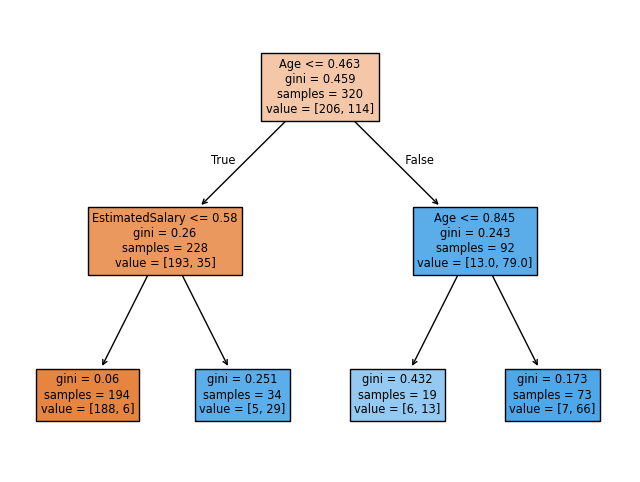

In [97]:
plt.figure(figsize=(8,6))
tree.plot_tree(c, feature_names = features.columns, filled=True)
plt.show()

In [98]:
# to deal with overfitting applying pruning techniques
mymodel(DecisionTreeClassifier(max_depth=15, min_samples_split=12))

Training Score :  0.95
Testing Score :  0.8875
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        51
           1       0.81      0.90      0.85        29

    accuracy                           0.89        80
   macro avg       0.88      0.89      0.88        80
weighted avg       0.89      0.89      0.89        80



DecisionTreeClassifier(max_depth=15, min_samples_split=12)

- 2. Random Forest -

In [99]:
r=mymodel(RandomForestClassifier())

Training Score :  1.0
Testing Score :  0.8875
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.94      0.88      0.91        51
           1       0.81      0.90      0.85        29

    accuracy                           0.89        80
   macro avg       0.88      0.89      0.88        80
weighted avg       0.89      0.89      0.89        80



In [100]:
# to deal with overfitting applying pruning techniques on random forest
r = mymodel(RandomForestClassifier(max_depth=2, n_estimators=70, max_leaf_nodes=15))
r

Training Score :  0.925
Testing Score :  0.8875
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.96      0.86      0.91        51
           1       0.79      0.93      0.86        29

    accuracy                           0.89        80
   macro avg       0.88      0.90      0.88        80
weighted avg       0.90      0.89      0.89        80



RandomForestClassifier(max_depth=2, max_leaf_nodes=15, n_estimators=70)

- 3. Adaptive Boost Classifier -

In [106]:
mymodel(AdaBoostClassifier())

Training Score :  0.915625
Testing Score :  0.875
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.88      0.90        51
           1       0.81      0.86      0.83        29

    accuracy                           0.88        80
   macro avg       0.86      0.87      0.87        80
weighted avg       0.88      0.88      0.88        80



AdaBoostClassifier()

In [107]:
mymodel(AdaBoostClassifier(n_estimators=40))
# n_estimators gives number of decision trees.It depends on the number of features we have.

Training Score :  0.91875
Testing Score :  0.875
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.92      0.88      0.90        51
           1       0.81      0.86      0.83        29

    accuracy                           0.88        80
   macro avg       0.86      0.87      0.87        80
weighted avg       0.88      0.88      0.88        80



AdaBoostClassifier(n_estimators=40)

- 4. Gradient Boosting Classifier -

In [108]:
mymodel(GradientBoostingClassifier(n_estimators=40))

Training Score :  0.95625
Testing Score :  0.9
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.96      0.88      0.92        51
           1       0.82      0.93      0.87        29

    accuracy                           0.90        80
   macro avg       0.89      0.91      0.89        80
weighted avg       0.91      0.90      0.90        80



GradientBoostingClassifier(n_estimators=40)

- 5. XGBoost Classifier -

In [101]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.


In [104]:
mymodel(XGBClassifier(n_estimators=80))

Training Score :  1.0
Testing Score :  0.875
Confusion Matrix : 
                Not Purchased  Purchased
Not Purchased             44          7
Purchased                  6         23
Classification Report : 
               precision    recall  f1-score   support

           0       0.94      0.86      0.90        51
           1       0.79      0.90      0.84        29

    accuracy                           0.88        80
   macro avg       0.86      0.88      0.87        80
weighted avg       0.88      0.88      0.88        80



XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=80,
              n_jobs=None, num_parallel_tree=None, ...)